In [36]:
!git clone https://github.com/jonschwenk/RivGraph.git

fatal: destination path 'RivGraph' already exists and is not an empty directory.


In [37]:
import os
os.chdir('/content/RivGraph')
os.listdir()

['CHANGELOG.md',
 'examples',
 'paper.md',
 'paper.bib',
 'README.md',
 '.gitattributes',
 'conda-osx-64.lock',
 '.github',
 'RivGraph',
 'LICENSE.txt',
 '.coveragerc',
 'pyproject.toml',
 'rivgraph',
 'conda-linux-64.lock',
 'environment.yml',
 'tests',
 'conda-win-64.lock',
 'conda-osx-arm64.lock',
 '.gitignore',
 'docs',
 '.git']

In [38]:
!pip install shapely --only-binary :all:
!pip install fastdtw loguru numpy scipy matplotlib scikit-image networkx opencv-python

In [39]:
!pip install scipy==1.11.4

In [40]:
import scipy
print(scipy.__version__)

1.11.4


In [41]:
import sys
sys.path.insert(0, '/content/RivGraph')

import rivgraph.classes as classes

print("Available classes in rivgraph.classes:")
print([name for name in dir(classes) if not name.startswith('_')])

Available classes in rivgraph.classes:
['CRS', 'LineString', 'centerline', 'cu', 'dd', 'delta', 'distance_transform_edt', 'dm', 'du', 'gdal', 'gpd', 'gu', 'io', 'lnu', 'logger', 'm2g', 'mu', 'np', 'nx', 'os', 'plt', 'rd', 'river', 'rivnetwork', 'ru', 'signal', 'sys']


In [42]:
import sys
sys.path.insert(0, '/content/RivGraph')

import rivgraph
print(dir(rivgraph))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'classes', 'deltas', 'directionality', 'geo_utils', 'im_utils', 'io_utils', 'ln_utils', 'mask_to_graph', 'mask_utils', 'ordered_set', 'rivers', 'walk']


In [43]:
from google.colab import drive
drive.mount('/content/drive')

import os

# List all files in your Drive to find the correct path
print("Files in your Drive:")
for root, dirs, files in os.walk('/content/drive/My Drive'):
    for file in files:
        if file.endswith(('.tif', '.tiff')):
            full_path = os.path.join(root, file)
            print(full_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in your Drive:
/content/drive/My Drive/Classroom/SIG 2022 Jumat 11 - 13/12019012_Valina Rizky P_AreaKerja.tif
/content/drive/My Drive/GEOTHERMAL/DEMNAS_0619-32_v1.0.tif
/content/drive/My Drive/GEOTHERMAL/DEMNAS_0619-31_v1.0.tif
/content/drive/My Drive/es2/Papua.tif
/content/drive/My Drive/es2/papua_skel.tif


In [44]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/RivGraph')

from shapely.ops import unary_union
import rivgraph.mask_utils
rivgraph.mask_utils.cascaded_union = unary_union

from rivgraph.classes import rivnetwork

# Use the EXACT path from the list above
rn = rivnetwork(
    name='delta',
    path_to_mask='/content/drive/My Drive/es2/Papua.tif'
)

print("✓ Image loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Image loaded successfully!


---------- New Run ----------


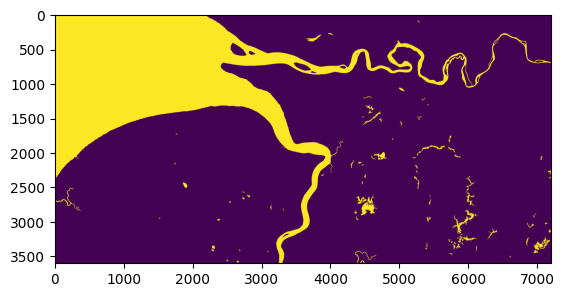

In [45]:
from rivgraph.classes import delta
import matplotlib.pyplot as plt

# Define the path to the georeferenced binary image.
mask_path = '/content/drive/My Drive/es2/Papua.tif'
# Results will be saved with this name
name = 'papua'

# Where do you want to store the results? This folder will be created if it doesn't exist.
results_folder = '/content/drive/My Drive/es2/'

# Boot up the delta class! We set verbose=True to see progress of processing.
papua = delta(name, mask_path, results_folder=results_folder, verbose=True)

# The mask has been re-binarized and stored as an attribute of colville:
plt.imshow(papua.Imask)

`np.NaN` not found in rivgraph/im_utils.py or already patched. Skipping patch.


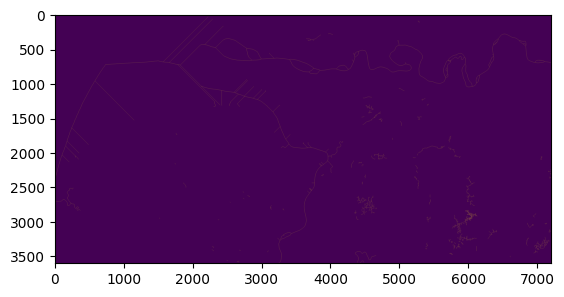

In [46]:
# Simply use the skeletonize() method.
import os
import sys
import importlib
import numpy as np # Ensure numpy is available for version check

# Define the path to the problematic file within the RivGraph installation
rivgraph_base_path = '/content/RivGraph' # Assuming RivGraph is cloned here
im_utils_file_path = os.path.join(rivgraph_base_path, 'rivgraph', 'im_utils.py')

# --- Start Patching Logic ---
try:
    with open(im_utils_file_path, 'r') as f:
        content = f.read()

    # Check if the problematic `np.NaN` exists in the file content
    if "vals[:] = np.NaN" in content:
        # Check if the current numpy version is 2.0 or higher
        if np.__version__.startswith('2.'):
            print("Found NumPy 2.0+ incompatible code in rivgraph/im_utils.py. Applying patch...")
            # Replace np.NaN with np.nan
            patched_content = content.replace("vals[:] = np.NaN", "vals[:] = np.nan")

            # Write back the patched content
            with open(im_utils_file_path, 'w') as f:
                f.write(patched_content)
            print("rivgraph/im_utils.py patched successfully.")

            # Attempt to reload modules that might have loaded the old code
            # Reload in dependency order: im_utils -> mask_to_graph -> classes
            if 'rivgraph.im_utils' in sys.modules:
                importlib.reload(sys.modules['rivgraph.im_utils'])
            if 'rivgraph.mask_to_graph' in sys.modules:
                importlib.reload(sys.modules['rivgraph.mask_to_graph'])
            # Re-import RivGraph classes, as the delta object's methods might refer to old module states
            from rivgraph.classes import delta
            from rivgraph.classes import rivnetwork # Also reload rivnetwork if used elsewhere

            print("Relevant RivGraph modules reloaded. Re-instantiating delta object...")
            # Re-instantiate the papua object to ensure it uses the newly loaded functions
            # Need to get original constructor arguments, which were name, mask_path, results_folder, verbose
            papua = delta(name='papua', mask_path='/content/drive/My Drive/es2/Papua.tif', results_folder='/content/drive/My Drive/es2/', verbose=True)
            print("Delta object re-instantiated.")
        else:
            print("NumPy version is < 2.0.0, no patch needed for np.NaN. Skipping patch.")
    else:
        print("`np.NaN` not found in rivgraph/im_utils.py or already patched. Skipping patch.")

except FileNotFoundError:
    print(f"Error: rivgraph/im_utils.py not found at {im_utils_file_path}. Cannot apply patch.")
except Exception as e:
    print(f"An error occurred during patching: {e}")
    # If patching fails, re-raise the original error or provide instructions
    print("Patching failed. Please consider manually downgrading NumPy to < 2.0.0, then restart the runtime.")
    print("Example: !pip uninstall numpy -y && !pip install numpy==1.26.4")

# --- End Patching Logic ---

# Now attempt to run the original code
papua.skeletonize()

# After running, colville has a new attribute: Iskel. Let's take a look.
plt.imshow(papua.Iskel)

In [47]:
# We use the write_geotiff() method with the "skeleton" option.
papua.to_geotiff('skeleton')

Geotiff written to /content/drive/My Drive/es2/papua_skel.tif.


In [48]:
# Simply use the compute_network() method.
papua.compute_network()

Resolving links and nodes...
links and nodes have been resolved.


In [49]:
# Now we can see that the "links" and "nodes" dictionaries have been added as colville attributes:
links = papua.links
nodes = papua.nodes
print('links: {}'.format(links.keys()))
print('nodes: {}'.format(nodes.keys()))

links: dict_keys(['idx', 'conn', 'id', 'n_networks'])
nodes: dict_keys(['idx', 'conn', 'id'])


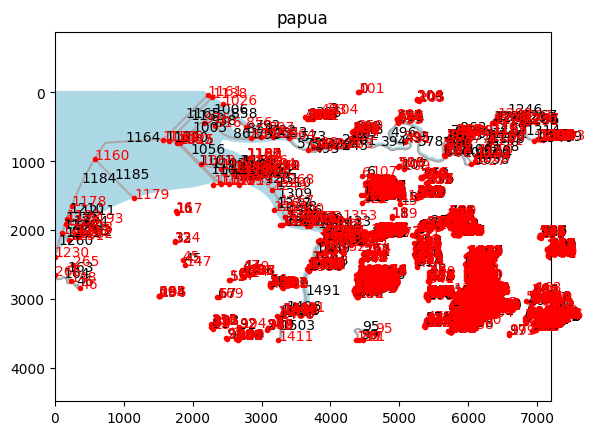

In [50]:
papua.plot('network')

In [51]:
papua.to_geovectors('network', ftype='json') # ftype can be either 'shp' or 'json'

# Let's see where the network geovector files were written:
print(papua.paths['links'])
print(papua.paths['nodes'])

/content/drive/My Drive/es2/papua_links.json
/content/drive/My Drive/es2/papua_nodes.json


In [52]:
import os

# List all files in the directory where shapefiles are expected
shapefile_dir = '/content/drive/My Drive/es2/'
print(f"Files in {shapefile_dir}:")
for root, dirs, files in os.walk(shapefile_dir):
    for file in files:
        print(os.path.join(root, file))

Files in /content/drive/My Drive/es2/:
/content/drive/My Drive/es2/Papua.tif
/content/drive/My Drive/es2/delta_log.log
/content/drive/My Drive/es2/papua_log.log
/content/drive/My Drive/es2/papua_skel.tif
/content/drive/My Drive/es2/papua_links.json
/content/drive/My Drive/es2/papua_nodes.json
/content/drive/My Drive/es2/inletpapua.shp
/content/drive/My Drive/es2/inletpapua.shx
/content/drive/My Drive/es2/inletpapua.qmd
/content/drive/My Drive/es2/inletpapua.cpg
/content/drive/My Drive/es2/inletpapua.prj
/content/drive/My Drive/es2/inletpapua.dbf
/content/drive/My Drive/es2/shorelinepapua.shx
/content/drive/My Drive/es2/shorelinepapua.prj
/content/drive/My Drive/es2/shorelinepapua.shp
/content/drive/My Drive/es2/shorelinepapua.cpg
/content/drive/My Drive/es2/shorelinepapua.qmd
/content/drive/My Drive/es2/shorelinepapua.dbf
/content/drive/My Drive/es2/soree.prj
/content/drive/My Drive/es2/soree.shp
/content/drive/My Drive/es2/soree.shx
/content/drive/My Drive/es2/soree.qmd
/content/drive

In [53]:
import geopandas as gpd

# Check inlet nodes
inlets = gpd.read_file('/content/drive/My Drive/es2/tit.shp')
print("Inlet nodes:")
print(inlets)
print("Geometry types:", inlets.geometry.type.unique())

# Check shoreline
shoreline = gpd.read_file('/content/drive/My Drive/es2/soree.shp')
print("\nShoreline:")
print(shoreline)
print("Geometry types:", shoreline.geometry.type.unique())

Inlet nodes:
   id                    geometry
0   1        POINT (140 -7.18805)
1   2  POINT (138.90085 -7.99943)
Geometry types: ['Point']

Shoreline:
   id                                           geometry
0 NaN  LINESTRING (138.58154 -6.98534, 138.61672 -7.0...
Geometry types: ['LineString']


SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (3597630658.py, line 2)

In [54]:
import scipy
print(scipy.__version__)

1.11.4


In [58]:
# Read the file
with open('/content/RivGraph/rivgraph/ln_utils.py', 'r') as f:
    lines = f.readlines()

# Find the line with "if m.count[0] > 1:" and fix it
for i, line in enumerate(lines):
    if 'if m.count[0] > 1:' in line:
        # Replace lines 893-895 (the problematic section)
        # Find the exact line numbers
        start_idx = i

        # Replace the problematic code
        lines[start_idx] = """            # Handle scipy 1.8+ compatibility
            count_val = m.count if isinstance(m.count, (int, float)) else m.count[0]
            if count_val > 1:
"""
        lines[start_idx + 1] = """                # Get link
                looplink = m.mode if isinstance(m.mode, (int, float)) else m.mode[0]
"""
        break

# Write back the file
with open('/content/RivGraph/rivgraph/ln_utils.py', 'w') as f:
    f.writelines(lines)

print("✅ File fixed successfully!")

✅ File fixed successfully!


In [59]:
papua.prune_network(path_shoreline='/content/drive/My Drive/es2/soree.shp',
                    path_inletnodes='/content/drive/My Drive/es2/tit.shp')

IndexError: invalid index to scalar variable.

In [ ]:
# Now run your RivGraph code
papua.prune_network(path_shoreline='/content/drive/My Drive/es2/soree.shp',
                    path_inletnodes='/content/drive/My Drive/es2/tit.shp')

In [ ]:
import scipy
print(scipy.__version__)